In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('../data/online_retail.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# 1. Drop rows with missing CustomerID (we can't use them)
df = df.dropna(subset=['CustomerID'])

# 2. Drop rows with missing Description (minor but keeps data clean)
df = df.dropna(subset=['Description'])

# 3. Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove rows where Quantity or UnitPrice is 0 or negative
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 5. Reset index
df = df.reset_index(drop=True)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (397884, 8)


In [7]:
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [10]:
# Reference date (one day after last transaction in dataset)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [11]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

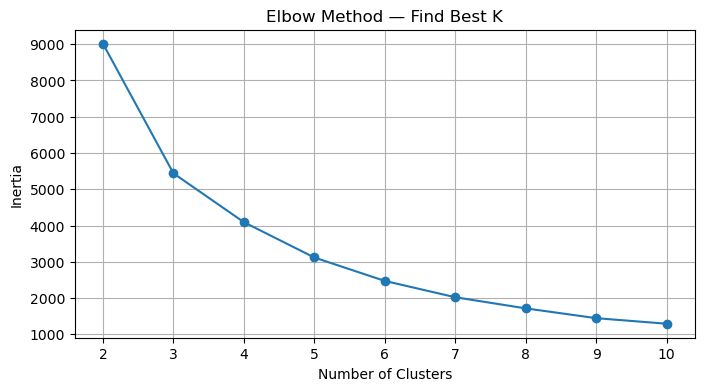

In [14]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method — Find Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [15]:
# We'll use 4 clusters (elbow usually suggests 3-5, we'll confirm after you see the chart)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [16]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1359.0
1          248.1        1.6     480.6
2            7.4       82.5  127338.3
3           15.5       22.3   12709.1


In [17]:
cluster_labels = {
    0: 'Regular',
    1: 'Dormant',
    2: 'VIP',
    3: 'Loyal'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal
1,12347.0,2,7,4310.00,0,Regular
2,12348.0,75,4,1797.24,0,Regular
3,12349.0,19,1,1757.55,0,Regular
4,12350.0,310,1,334.40,1,Dormant
5,12352.0,36,8,2506.04,0,Regular
6,12353.0,204,1,89.00,1,Dormant
7,12354.0,232,1,1079.40,1,Dormant
8,12355.0,214,1,459.40,1,Dormant
9,12356.0,23,3,2811.43,0,Regular


In [18]:
print(rfm['Segment'].value_counts())

Segment
Regular    3054
Dormant    1067
Loyal       204
VIP          13
Name: count, dtype: int64


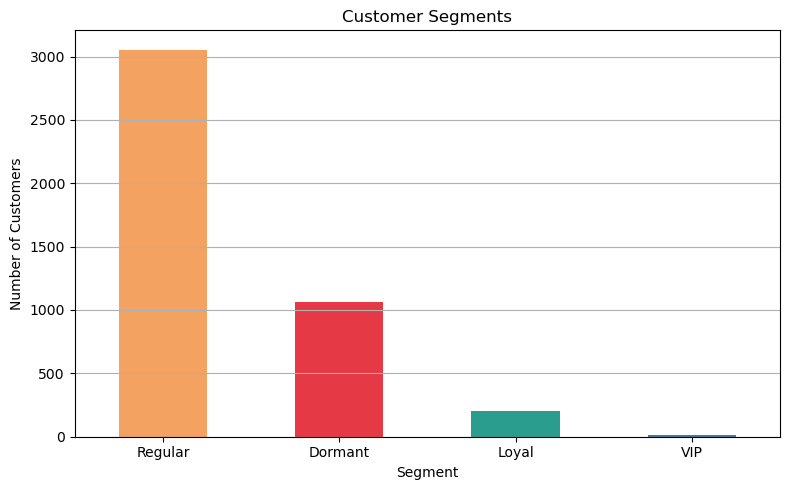

In [19]:
plt.figure(figsize=(8, 5))
colors = ['#f4a261', '#e63946', '#2a9d8f', '#457b9d']
rfm['Segment'].value_counts().plot(kind='bar', color=colors)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

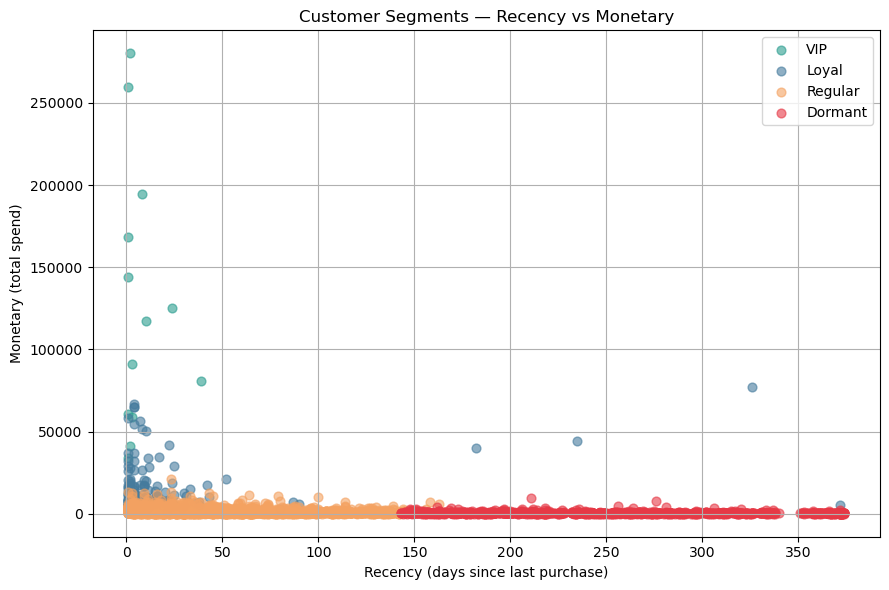

In [20]:
plt.figure(figsize=(9, 6))
colors_map = {'VIP': '#2a9d8f', 'Loyal': '#457b9d', 'Regular': '#f4a261', 'Dormant': '#e63946'}

for segment, color in colors_map.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Monetary'], 
                label=segment, color=color, alpha=0.6, s=40)

plt.title('Customer Segments — Recency vs Monetary')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Anyone who hasn't bought in 90+ days = churned
rfm['Churned'] = (rfm['Recency'] >= 90).astype(int)

print(rfm['Churned'].value_counts())
print("\nChurn Rate:", round(rfm['Churned'].mean() * 100, 1), "%")

Churned
0    2880
1    1458
Name: count, dtype: int64

Churn Rate: 33.6 %


In [22]:
from sklearn.model_selection import train_test_split

features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (3470, 3)
Testing size: (868, 3)


In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00       308

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [25]:
rfm['Churn_Probability'] = model.predict_proba(X_test)[:, 1].mean()

# Get probability for every customer
rfm['Churn_Probability'] = model.predict_proba(rfm[features])[:, 1]
rfm['Churn_Probability'] = (rfm['Churn_Probability'] * 100).round(1)

rfm[['CustomerID', 'Segment', 'Recency', 'Churn_Probability']].head(10)

,CustomerID,Segment,Recency,Churn_Probability
0,12346.0,Loyal,326,99.0
1,12347.0,Regular,2,0.0
2,12348.0,Regular,75,0.0
3,12349.0,Regular,19,0.0
4,12350.0,Dormant,310,100.0
5,12352.0,Regular,36,0.0
6,12353.0,Dormant,204,100.0
7,12354.0,Dormant,232,100.0
8,12355.0,Dormant,214,100.0
9,12356.0,Regular,23,0.0


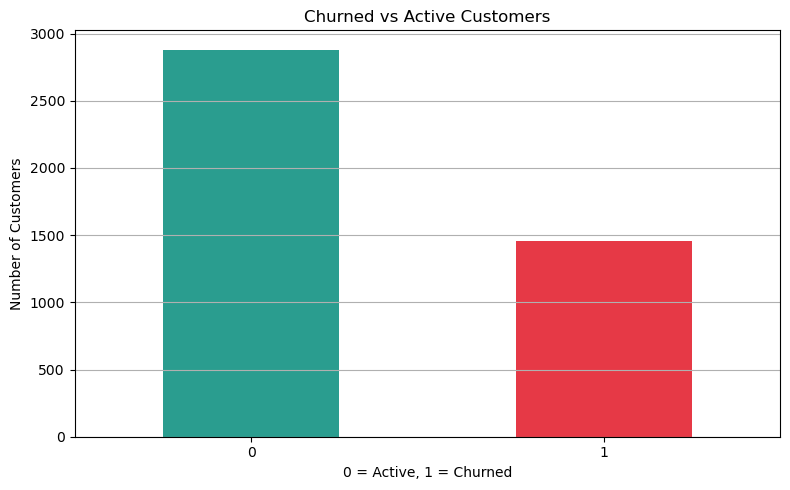

In [26]:
plt.figure(figsize=(8, 5))
rfm['Churned'].value_counts().plot(kind='bar', color=['#2a9d8f', '#e63946'])
plt.title('Churned vs Active Customers')
plt.xlabel('0 = Active, 1 = Churned')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

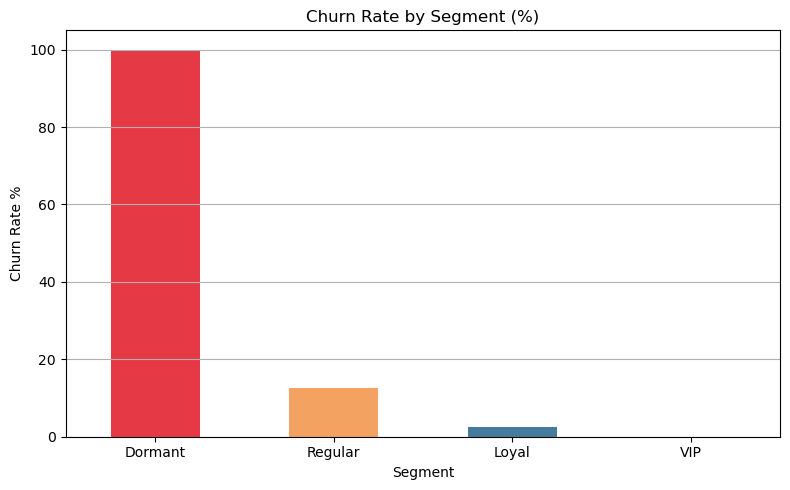

In [27]:
churn_by_segment = rfm.groupby('Segment')['Churned'].mean() * 100

plt.figure(figsize=(8, 5))
colors = ['#e63946', '#f4a261', '#457b9d', '#2a9d8f']
churn_by_segment.sort_values(ascending=False).plot(kind='bar', color=colors)
plt.title('Churn Rate by Segment (%)')
plt.xlabel('Segment')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [28]:
high_risk = rfm[rfm['Churn_Probability'] >= 70]\
    .sort_values('Monetary', ascending=False)\
    [['CustomerID', 'Segment', 'Recency', 'Frequency', 'Monetary', 'Churn_Probability']]\
    .head(10)

print("🔴 High Risk Customers Worth Saving:")
print(high_risk)

🔴 High Risk Customers Worth Saving:
      CustomerID  Segment  Recency  Frequency  Monetary  Churn_Probability
0        12346.0    Loyal      326          1  77183.60               99.0
2502     15749.0    Loyal      235          3  44534.30               99.0
2011     15098.0    Loyal      182          3  39916.50               98.0
2814     16180.0  Regular      100          8  10254.18               98.0
196      12590.0  Dormant      211          2   9864.26               98.0
566      13093.0  Dormant      276          8   7832.47               99.0
485      12980.0  Regular      158          9   7374.90               97.0
519      13027.0  Regular      114          6   6912.00               99.0
2637     15939.0    Loyal       90         15   6115.01               88.0
3083     16553.0  Regular      163         12   5719.82               94.0


In [29]:
# Create a basket: which customers bought which products
basket = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Convert to binary (bought or not)
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket shape:", basket_binary.shape)
basket_binary.head()

C:\Users\heetp\AppData\Local\Temp\ipykernel_2448\2379946838.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)


Basket shape: (4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculate similarity between customers
customer_similarity = cosine_similarity(basket_binary)
customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=basket_binary.index,
    columns=basket_binary.index
)

def get_recommendations(customer_id, n_recommendations=5):
    # Check if customer exists
    if customer_id not in customer_similarity_df.index:
        return f"Customer {customer_id} not found"
    
    # Find most similar customers
    similar_customers = customer_similarity_df[customer_id]\
        .sort_values(ascending=False)[1:6].index
    
    # Find what they bought that our customer hasn't
    customer_products = set(basket_binary.loc[customer_id][basket_binary.loc[customer_id] > 0].index)
    
    recommendations = {}
    for similar in similar_customers:
        similar_products = set(basket_binary.loc[similar][basket_binary.loc[similar] > 0].index)
        new_products = similar_products - customer_products
        for product in new_products:
            recommendations[product] = recommendations.get(product, 0) + 1
    
    # Return top N recommendations
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [product for product, score in top_recommendations]

print("Recommendation function ready ✅")

Recommendation function ready ✅


In [31]:
# Test with a real customer from our dataset
test_customer = rfm['CustomerID'].iloc[0]

print(f"Customer ID: {test_customer}")
print(f"Segment: {rfm[rfm['CustomerID'] == test_customer]['Segment'].values[0]}")
print(f"\n🛍️ Recommended Products:")
recs = get_recommendations(test_customer)
for i, product in enumerate(recs, 1):
    print(f"  {i}. {product}")

Customer ID: 12346.0
Segment: Loyal

🛍️ Recommended Products:


C:\Users\heetp\AppData\Local\Temp\ipykernel_2448\1585415752.py:18: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  similar_customers = customer_similarity_df[customer_id]\


KeyError: 1

In [32]:
# Convert CustomerID to integer to avoid float mismatch
df['CustomerID'] = df['CustomerID'].astype(int)
rfm['CustomerID'] = rfm['CustomerID'].astype(int)

# Create basket
basket = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket shape:", basket_binary.shape)
basket_binary.head()


C:\Users\heetp\AppData\Local\Temp\ipykernel_2448\837924122.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)


Basket shape: (4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

customer_similarity = cosine_similarity(basket_binary)
customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=basket_binary.index,
    columns=basket_binary.index
)

def get_recommendations(customer_id, n_recommendations=5):
    customer_id = int(customer_id)  # force integer
    
    if customer_id not in customer_similarity_df.index:
        return f"Customer {customer_id} not found"
    
    similar_customers = customer_similarity_df[customer_id]\
        .sort_values(ascending=False)[1:6].index
    
    customer_products = set(basket_binary.loc[customer_id][basket_binary.loc[customer_id] > 0].index)
    
    recommendations = {}
    for similar in similar_customers:
        similar_products = set(basket_binary.loc[similar][basket_binary.loc[similar] > 0].index)
        new_products = similar_products - customer_products
        for product in new_products:
            recommendations[product] = recommendations.get(product, 0) + 1
    
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [product for product, score in top_recommendations]

print("Ready ✅")

Ready ✅


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

customer_similarity = cosine_similarity(basket_binary)
customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=basket_binary.index,
    columns=basket_binary.index
)

def get_recommendations(customer_id, n_recommendations=5):
    customer_id = int(customer_id)  # force integer
    
    if customer_id not in customer_similarity_df.index:
        return f"Customer {customer_id} not found"
    
    similar_customers = customer_similarity_df[customer_id]\
        .sort_values(ascending=False)[1:6].index
    
    customer_products = set(basket_binary.loc[customer_id][basket_binary.loc[customer_id] > 0].index)
    
    recommendations = {}
    for similar in similar_customers:
        similar_products = set(basket_binary.loc[similar][basket_binary.loc[similar] > 0].index)
        new_products = similar_products - customer_products
        for product in new_products:
            recommendations[product] = recommendations.get(product, 0) + 1
    
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
    return [product for product, score in top_recommendations]

print("Ready ✅")

Ready ✅


In [35]:
test_customer = int(rfm['CustomerID'].iloc[0])

print(f"Customer ID: {test_customer}")
print(f"Segment: {rfm[rfm['CustomerID'] == test_customer]['Segment'].values[0]}")
print(f"\n🛍️ Recommended Products:")
recs = get_recommendations(test_customer)
for i, product in enumerate(recs, 1):
    print(f"  {i}. {product}")

Customer ID: 12346
Segment: Loyal

🛍️ Recommended Products:
  1. SMALL CERAMIC TOP STORAGE JAR 
  2. PICNIC BASKET WICKER LARGE
  3. FOOT STOOL HOME SWEET HOME 
  4. CUPBOARD 3 DRAWER MA CAMPAGNE
  5. HOMEMADE JAM SCENTED CANDLES


In [36]:
high_risk_customer = 12346

print(f"Customer ID: {high_risk_customer}")
print(f"\n🛍️ Recommended Products to Win Them Back:")
recs = get_recommendations(high_risk_customer)
for i, product in enumerate(recs, 1):
    print(f"  {i}. {product}")

Customer ID: 12346

🛍️ Recommended Products to Win Them Back:
  1. SMALL CERAMIC TOP STORAGE JAR 
  2. PICNIC BASKET WICKER LARGE
  3. FOOT STOOL HOME SWEET HOME 
  4. CUPBOARD 3 DRAWER MA CAMPAGNE
  5. HOMEMADE JAM SCENTED CANDLES


In [37]:
import os

# Create output folder
os.makedirs('../outputs', exist_ok=True)

# Save RFM with segments and churn
rfm.to_csv('../outputs/rfm_final.csv', index=False)

# Save cleaned dataframe
df.to_csv('../outputs/cleaned_retail.csv', index=False)

# Save basket binary for recommendations
basket_binary.to_csv('../outputs/basket_binary.csv')

print("✅ All files saved to outputs/ folder")
print(rfm.columns.tolist())

✅ All files saved to outputs/ folder
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'Churned', 'Churn_Probability']
